<a href="https://colab.research.google.com/github/mathy-analyst/training1/blob/tests_colab/Hands_on_Lab_Finding_Duplicates_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset.


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [ ]:
!pip install pandas
!pip install matplotlib

Import pandas module


In [ ]:
import pandas as pd


Import matplotlib


In [ ]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [ ]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [ ]:
## Write your code here
# Compter le nombre de doublons
duplicate_count = df.duplicated().sum()
print(f"nombre total de doublons:{duplicate_count}")
# Afficher les premières lignes dupliquées
duplicates_rows = df[df.duplicated(keep='first')]
print(duplicates_rows.head())

nombre total de doublons:20
       ResponseId                      MainBranch                 Age  \
65437           1  I am a developer by profession  Under 18 years old   
65438           2  I am a developer by profession     35-44 years old   
65439           3  I am a developer by profession     45-54 years old   
65440           4           I am learning to code     18-24 years old   
65441           5  I am a developer by profession     18-24 years old   

                Employment RemoteWork   Check  \
65437  Employed, full-time     Remote  Apples   
65438  Employed, full-time     Remote  Apples   
65439  Employed, full-time     Remote  Apples   
65440   Student, full-time        NaN  Apples   
65441   Student, full-time        NaN  Apples   

                                        CodingActivities  \
65437                                              Hobby   
65438  Hobby;Contribute to open-source projects;Other...   
65439  Hobby;Contribute to open-source projects;Other...  

### Task 2: Analyze Characteristics of Duplicates
1. Identify duplicate rows based on selected columns such as MainBranch, Employment, and RemoteWork. Analyse which columns frequently contain identical values within these duplicate rows.
2. Analyse the characteristics of rows that are duplicates based on a subset of columns, such as MainBranch, Employment, and RemoteWork. Determine which columns frequently have identical values across these rows.
   


In [ ]:
## Write your code here
subset_columns = ['MainBranch', 'Employment', 'RemoteWork']
subset_duplicates = df[df.duplicated(subset=subset_columns, keep=False)]
print("Duplicate rows based on MainBranch, Employment, and RemoteWork:")
display(subset_duplicates.head())

# Analyze characteristics of subset duplicates
print("\nAnalyzing characteristics of subset duplicates:")
for col in subset_columns:
    print(f"\nValue counts for '{col}' in subset duplicates:")
    display(subset_duplicates[col].value_counts())

# Further analysis: check for identical values in other columns for these subset duplicates
print("\nChecking for frequently identical values in other columns:")
# Select a few other columns to check
other_columns_to_check = ['Age', 'EdLevel', 'Country'] # Add other relevant columns here

for col in other_columns_to_check:
    print(f"\nValue counts for '{col}' in subset duplicates:")
    display(subset_duplicates[col].value_counts())

Duplicate rows based on MainBranch, Employment, and RemoteWork:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN



Analyzing characteristics of subset duplicates:

Value counts for 'MainBranch' in subset duplicates:


,count
MainBranch,
I am a developer by profession,50173
"I am not primarily a developer, but I write code sometimes as part of my work/studies",6471
I am learning to code,3847
I code primarily as a hobby,3317
"I used to be a developer by profession, but no longer am",1482



Value counts for 'Employment' in subset duplicates:


...

,count
Age,
25-34 years old,23878
35-44 years old,14926
18-24 years old,14054
45-54 years old,6243
55-64 years old,2565
Under 18 years old,2552
65 years or older,754
Prefer not to say,318



Value counts for 'EdLevel' in subset duplicates:


,count
EdLevel,
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",24910
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",15537
Some college/university study without earning a degree,7623
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",5775
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",2964
"Associate degree (A.A., A.S., etc.)",1786
Primary/elementary school,1140
Something else,923



Value counts for 'Country' in subset duplicates:


,count
Country,
United States of America,11065
Germany,4946
India,4222
United Kingdom of Great Britain and Northern Ireland,3224
Ukraine,2664
...,...
"Micronesia, Federated States of...",1
Nauru,1
Chad,1


### Task 3: Visualize Duplicates Distribution
1. Create visualizations to show the distribution of duplicates across different categories.
2. Use bar charts or pie charts to represent the distribution of duplicates by Country and Employment.


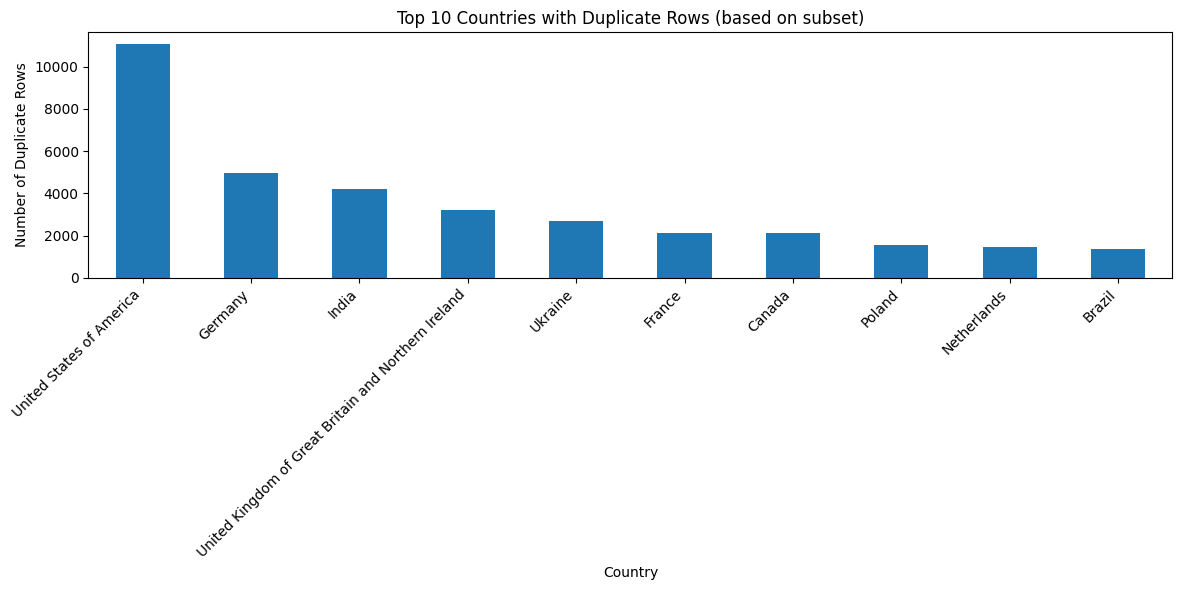

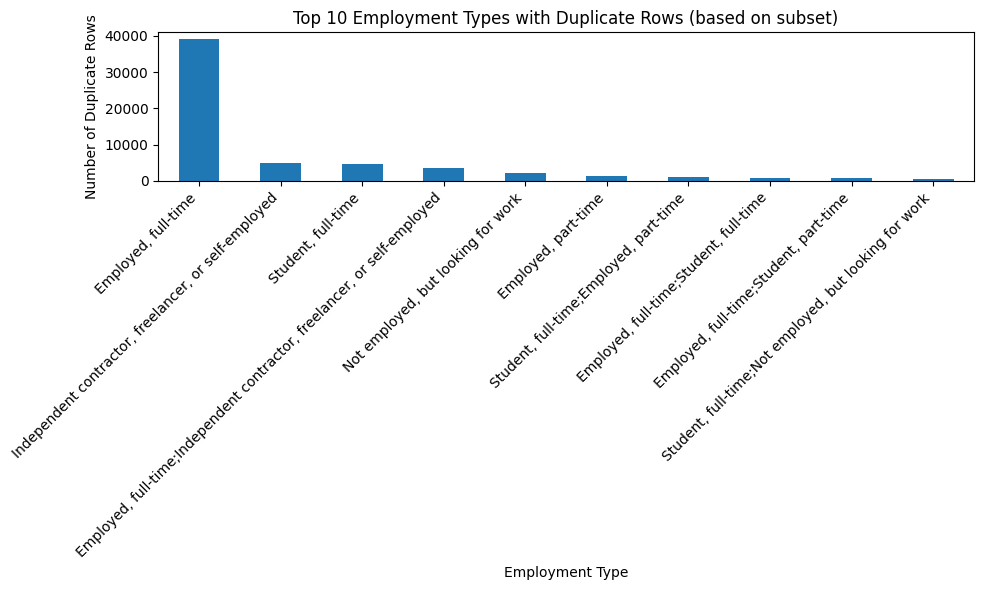

In [ ]:
## Write your code here
# Visualize distribution of duplicates by Country
plt.figure(figsize=(12, 6))
subset_duplicates['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries with Duplicate Rows (based on subset)')
plt.xlabel('Country')
plt.ylabel('Number of Duplicate Rows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize distribution of duplicates by Employment
plt.figure(figsize=(10, 6))
subset_duplicates['Employment'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Employment Types with Duplicate Rows (based on subset)')
plt.xlabel('Employment Type')
plt.ylabel('Number of Duplicate Rows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 4: Strategic Removal of Duplicates
1. Decide which columns are critical for defining uniqueness in the dataset.
2. Remove duplicates based on a subset of columns if complete row duplication is not a good criterion.


In [ ]:
## Write your code here
# Decide on critical columns for uniqueness (based on previous analysis)
critical_columns = ['MainBranch', 'Employment', 'RemoteWork']

# Remove duplicates based on the subset of columns
df_cleaned = df.drop_duplicates(subset=critical_columns, keep='first')

# Verify duplicate removal
print(f"Number of rows before removing subset duplicates: {len(df)}")
print(f"Number of rows after removing subset duplicates: {len(df_cleaned)}")
print(f"Number of subset duplicates remaining: {df_cleaned.duplicated(subset=critical_columns).sum()}")

Number of rows before removing subset duplicates: 65457
Number of rows after removing subset duplicates: 561
Number of subset duplicates remaining: 0


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
